# 实验十五：小波变换与多分辨率处理

## 一、知识点导入
小波变换（Wavelet Transform）是一种**同时具有时空（或空频）局部化能力**的分析方法。
在数字图像处理中，二维离散小波变换（2D-DWT）可以把图像分解为：
- 低频近似子带（LL）：表示图像整体轮廓与主要亮度结构；
- 高频细节子带（HL, LH, HH）：表示水平、垂直、对角方向的边缘与纹理。

多分辨率分析（MRA）是指：
- 在粗尺度看整体结构；
- 在细尺度看局部细节；
- 通过多层分解建立从“全局到局部”的层次表示。

这使得小波特别适合用于图像去噪、压缩、特征提取等任务。

## 二、实验目的与内容

### 实验目的
1. 掌握二维离散小波变换（DWT）的基本原理。
2. 理解多分辨率结构在图像分析中的意义。
3. 对比小波阈值去噪与空域平滑在边缘保持方面的差异。

### 实验内容
1. 使用 Haar 小波基对图像进行单层分解，获取近似（LL）与细节（HL, LH, HH）子带。
2. 进行多层小波分解，理解多分辨率结构。
3. 实现小波阈值去噪，并与空域平滑算法对比边缘保留效果。

## 三、环境准备
建议使用 Python 3.9+，需要以下库：`numpy`、`matplotlib`、`pywt`、`scipy`、`scikit-image`。

如果缺少库，可在终端或 notebook 中安装：
`pip install numpy matplotlib PyWavelets scipy scikit-image`

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

from scipy.ndimage import gaussian_filter, median_filter
from skimage import data, img_as_float
from skimage.draw import disk, rectangle_perimeter, line
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('库导入完成。')

库导入完成。


## 四、实验数据准备：生成教学用图像素材
为了便于观察小波在不同频率区域的响应，我们构造一张包含：
- 平滑区域；
- 几何边缘（矩形边框、直线）；
- 曲线结构（圆盘）；
- 纹理区域（正弦条纹）。

并同时给出一张真实图像（`camera`）作为应用素材。

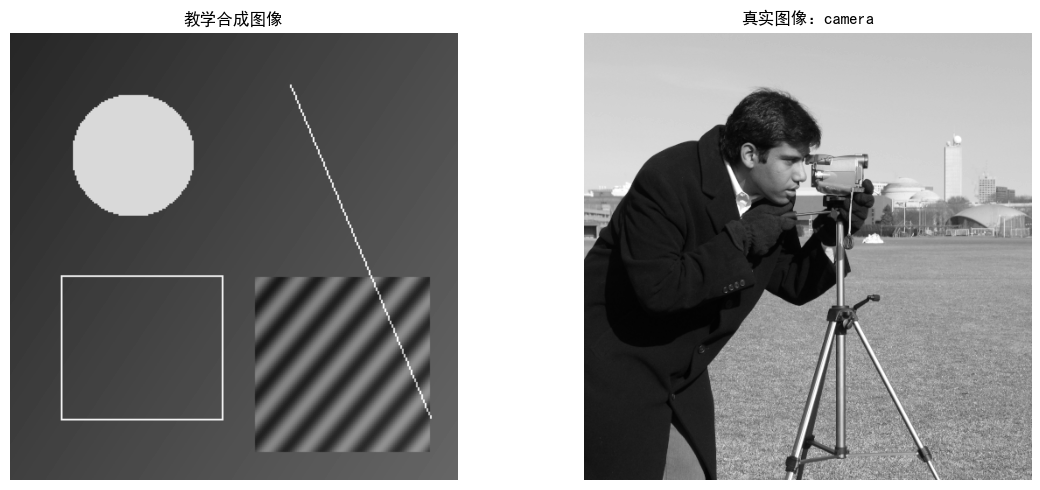

合成图像尺寸: (256, 256)
真实图像尺寸: (512, 512)


In [3]:
def normalize01(img):
    img = np.asarray(img, dtype=np.float64)
    min_v, max_v = img.min(), img.max()
    if max_v - min_v < 1e-12:
        return np.zeros_like(img)
    return (img - min_v) / (max_v - min_v)


def generate_teaching_image(size=256):
    img = np.zeros((size, size), dtype=np.float64) + 0.15

    # 平滑梯度背景
    yy, xx = np.meshgrid(np.linspace(0, 1, size), np.linspace(0, 1, size), indexing='ij')
    img += 0.25 * (0.6 * xx + 0.4 * yy)

    # 圆盘
    rr, cc = disk((70, 70), 35, shape=img.shape)
    img[rr, cc] = 0.85

    # 矩形边框
    rr, cc = rectangle_perimeter(start=(140, 30), end=(220, 120), shape=img.shape)
    img[rr, cc] = 0.95

    # 斜线
    rr, cc = line(30, 160, 220, 240)
    img[rr, cc] = 0.98

    # 正弦纹理块
    texture = 0.2 * np.sin(2 * np.pi * (12 * xx + 10 * yy))
    mask = np.zeros_like(img, dtype=bool)
    mask[140:240, 140:240] = True
    img[mask] += texture[mask]

    return np.clip(img, 0, 1)

synthetic_img = generate_teaching_image(256)
real_img = img_as_float(data.camera())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(synthetic_img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('教学合成图像')
axes[0].axis('off')

axes[1].imshow(real_img, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('真实图像：camera')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('合成图像尺寸:', synthetic_img.shape)
print('真实图像尺寸:', real_img.shape)

## 五、单层二维 Haar 小波分解
对图像做一次二维 DWT：
- `LL`：低频近似分量（轮廓与主体能量）；
- `cH, cV, cD`：三个方向的细节。

为与教材符号对应，可近似理解为：
- `HL` 对应垂直细节（`cV`）；
- `LH` 对应水平细节（`cH`）；
- `HH` 对应对角细节（`cD`）。

原图尺寸: (256, 256)
LL尺寸: (128, 128)
cH/cV/cD尺寸: (128, 128) (128, 128) (128, 128)


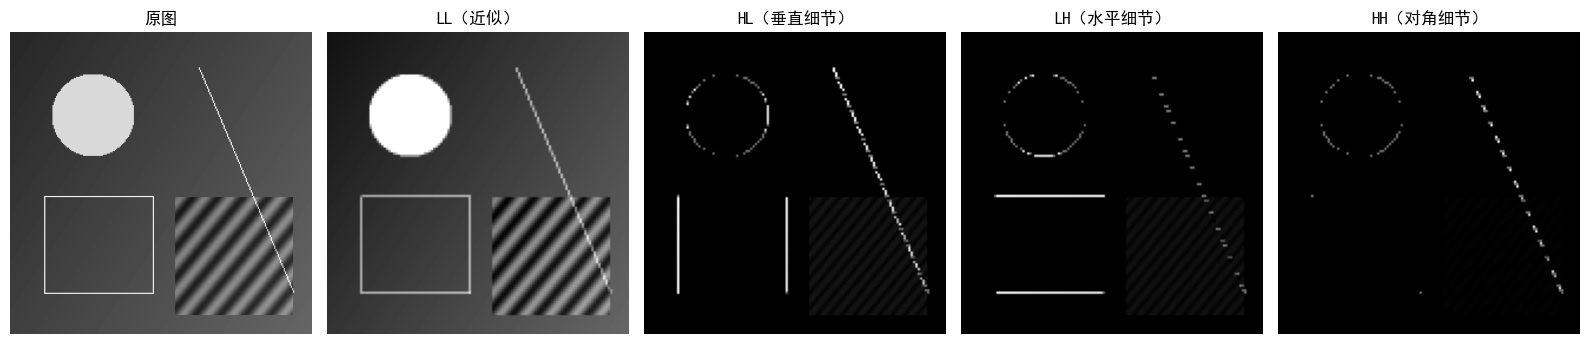


单层子带能量占比：
LL      : 0.9813
HL(cV)  : 0.0095
LH(cH)  : 0.0072
HH(cD)  : 0.0020


In [4]:
target_img = synthetic_img
coeffs_1 = pywt.dwt2(target_img, 'haar')
LL, (cH, cV, cD) = coeffs_1

print('原图尺寸:', target_img.shape)
print('LL尺寸:', LL.shape)
print('cH/cV/cD尺寸:', cH.shape, cV.shape, cD.shape)

# 归一化后便于显示
show_LL = normalize01(LL)
show_HL = normalize01(np.abs(cV))  # 与教材HL符号近似对应
show_LH = normalize01(np.abs(cH))  # 与教材LH符号近似对应
show_HH = normalize01(np.abs(cD))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.8))
axes[0].imshow(target_img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('原图')
axes[0].axis('off')

axes[1].imshow(show_LL, cmap='gray')
axes[1].set_title('LL（近似）')
axes[1].axis('off')

axes[2].imshow(show_HL, cmap='gray')
axes[2].set_title('HL（垂直细节）')
axes[2].axis('off')

axes[3].imshow(show_LH, cmap='gray')
axes[3].set_title('LH（水平细节）')
axes[3].axis('off')

axes[4].imshow(show_HH, cmap='gray')
axes[4].set_title('HH（对角细节）')
axes[4].axis('off')

plt.tight_layout()
plt.show()

energy = {
    'LL': np.sum(LL**2),
    'HL(cV)': np.sum(cV**2),
    'LH(cH)': np.sum(cH**2),
    'HH(cD)': np.sum(cD**2),
}
energy_sum = sum(energy.values())
print('\n单层子带能量占比：')
for k, v in energy.items():
    print(f'{k:8s}: {v/energy_sum:.4f}')

## 六、多层小波分解与多分辨率结构
继续对 `LL` 递归分解可得到多层结构：
- 层数越高，表示越粗尺度的信息；
- 高频子带在不同层上反映不同尺度的边缘与纹理。

下面以 3 层分解为例，并统计各层细节能量。

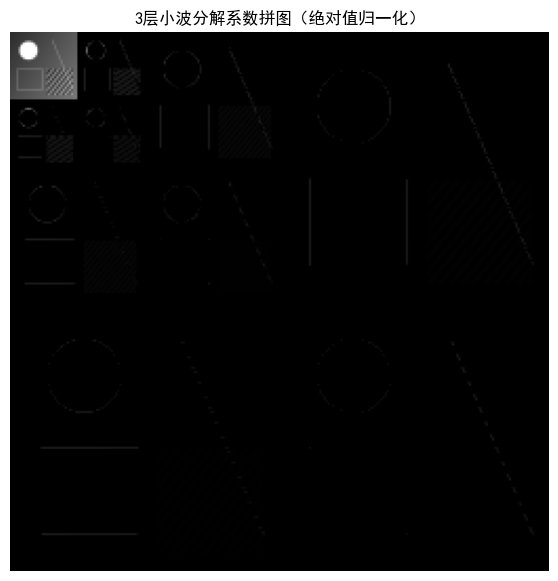

最粗尺度近似分量 cA3 尺寸: (32, 32)
各层细节分量尺寸:
  level 3: (32, 32)
  level 4: (64, 64)
  level 5: (128, 128)

各层细节能量统计（level: H/V/D）:
  level 3: 67.54 / 84.65 / 18.32
  level 4: 45.43 / 58.45 / 10.02
  level 5: 59.98 / 79.84 / 16.51


In [5]:
coeffs_3 = pywt.wavedec2(target_img, wavelet='haar', level=3)
# coeffs_3 结构: [cA3, (cH3,cV3,cD3), (cH2,cV2,cD2), (cH1,cV1,cD1)]

arr, slices = pywt.coeffs_to_array(coeffs_3)

plt.figure(figsize=(7, 7))
plt.imshow(normalize01(np.abs(arr)), cmap='gray')
plt.title('3层小波分解系数拼图（绝对值归一化）')
plt.axis('off')
plt.show()

print('最粗尺度近似分量 cA3 尺寸:', coeffs_3[0].shape)
print('各层细节分量尺寸:')
for i, detail in enumerate(coeffs_3[1:], start=3):
    cH_i, cV_i, cD_i = detail
    print(f'  level {i}:', cH_i.shape)

print('\n各层细节能量统计（level: H/V/D）:')
for idx, detail in enumerate(coeffs_3[1:], start=3):
    cH_i, cV_i, cD_i = detail
    eH = np.sum(cH_i**2)
    eV = np.sum(cV_i**2)
    eD = np.sum(cD_i**2)
    print(f'  level {idx}: {eH:.2f} / {eV:.2f} / {eD:.2f}')

## 七、小波阈值去噪 vs 空域平滑
实验流程：
1. 给图像添加高斯噪声；
2. 使用小波软阈值（soft-threshold）去噪；
3. 使用空域方法（高斯滤波、中值滤波）去噪；
4. 比较 PSNR / SSIM，并观察边缘保留情况。

加噪标准差(设定): 0.0800
小波估计噪声sigma: 0.0796
小波阈值: 0.3975

去噪效果指标（相对于原始 clean 图像）:
Noisy    -> PSNR:  22.25 dB, SSIM: 0.3610
Wavelet  -> PSNR:  24.74 dB, SSIM: 0.6544
Gaussian -> PSNR:  27.88 dB, SSIM: 0.6939
Median   -> PSNR:  26.86 dB, SSIM: 0.5672


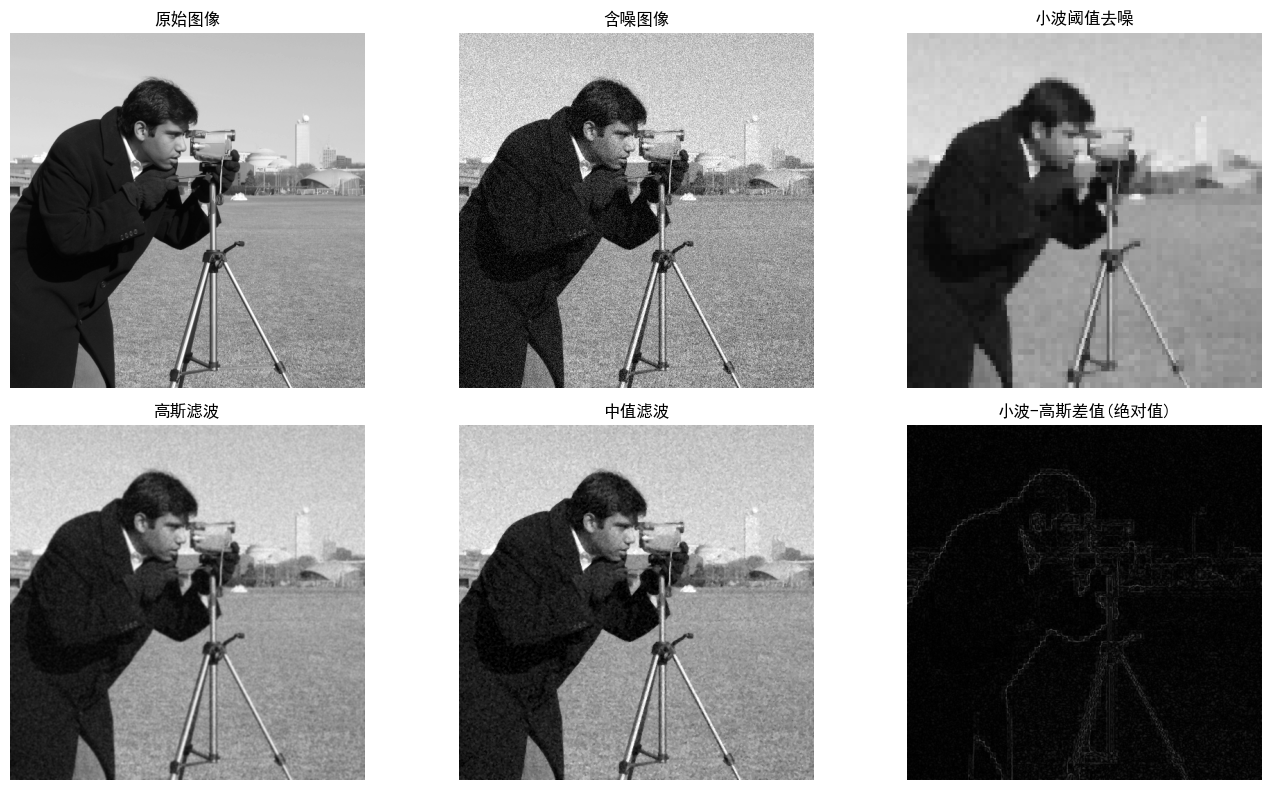

In [6]:
def wavelet_denoise(img, wavelet='haar', level=3, mode='soft'):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)

    # 利用第一层对角细节估计噪声方差（MAD）
    cH1, cV1, cD1 = coeffs[-1]
    sigma = np.median(np.abs(cD1)) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(img.size))

    denoised_coeffs = [coeffs[0]]
    for detail in coeffs[1:]:
        denoised_detail = tuple(pywt.threshold(d, value=uthresh, mode=mode) for d in detail)
        denoised_coeffs.append(denoised_detail)

    rec = pywt.waverec2(denoised_coeffs, wavelet=wavelet)
    rec = rec[:img.shape[0], :img.shape[1]]
    rec = np.clip(rec, 0, 1)
    return rec, sigma, uthresh

clean = real_img
noise_sigma = 0.08
noisy = np.clip(clean + noise_sigma * np.random.randn(*clean.shape), 0, 1)

wave_denoised, est_sigma, th = wavelet_denoise(noisy, wavelet='haar', level=3, mode='soft')
gauss_denoised = gaussian_filter(noisy, sigma=1.0)
median_denoised = median_filter(noisy, size=3)

methods = {
    'Noisy': noisy,
    'Wavelet': wave_denoised,
    'Gaussian': gauss_denoised,
    'Median': median_denoised,
}

print(f'加噪标准差(设定): {noise_sigma:.4f}')
print(f'小波估计噪声sigma: {est_sigma:.4f}')
print(f'小波阈值: {th:.4f}\n')

print('去噪效果指标（相对于原始 clean 图像）:')
for name, img_m in methods.items():
    psnr = peak_signal_noise_ratio(clean, img_m, data_range=1.0)
    ssim = structural_similarity(clean, img_m, data_range=1.0)
    print(f'{name:8s} -> PSNR: {psnr:6.2f} dB, SSIM: {ssim:.4f}')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

show_list = [
    ('原始图像', clean),
    ('含噪图像', noisy),
    ('小波阈值去噪', wave_denoised),
    ('高斯滤波', gauss_denoised),
    ('中值滤波', median_denoised),
    ('小波-高斯差值(绝对值)', np.abs(wave_denoised - gauss_denoised)),
]

for ax, (title, img_show) in zip(axes, show_list):
    ax.imshow(img_show, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 八、案例应用模块：给定一张图像，执行小波多分辨率处理
本模块用于课堂作业或课程设计：
- 输入任意灰度图；
- 输出单层子带、多层系数图、去噪结果与评价指标。

你可以将自己的图片路径赋值给 `user_image_path`（例如拍摄的文档、遥感图像、医学图像切片等）。

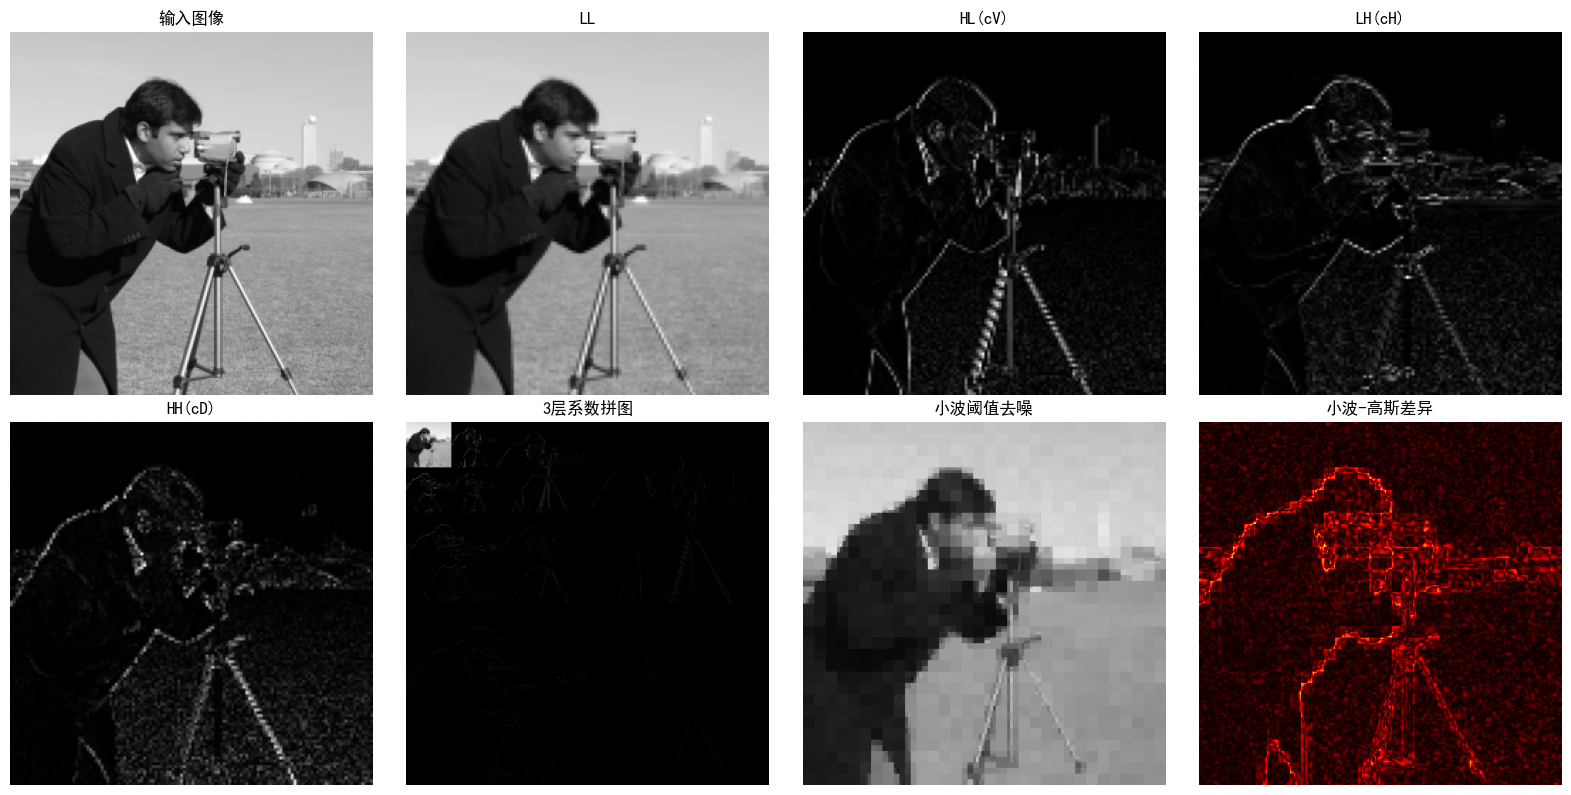

应用模块指标：
估计噪声 sigma = 0.0782, 阈值 = 0.3681
Noisy    -> PSNR:  22.22 dB, SSIM: 0.3638
Wavelet  -> PSNR:  24.22 dB, SSIM: 0.6768
Gaussian -> PSNR:  27.68 dB, SSIM: 0.7227


In [7]:
from skimage import io, color, transform

def load_gray_image(path=None, fallback=data.camera(), out_shape=(256, 256)):
    if path is None:
        img = img_as_float(fallback)
    else:
        img = io.imread(path)
        img = img_as_float(img)
        if img.ndim == 3:
            img = color.rgb2gray(img)
    if out_shape is not None:
        img = transform.resize(img, out_shape, anti_aliasing=True)
    return np.clip(img, 0, 1)


def run_wavelet_pipeline(img, wavelet='haar', level=3):
    # 单层分解
    LL, (cH, cV, cD) = pywt.dwt2(img, wavelet)

    # 多层分解
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    arr, _ = pywt.coeffs_to_array(coeffs)

    # 加噪与去噪
    noisy = np.clip(img + 0.08 * np.random.randn(*img.shape), 0, 1)
    den_w, est_sigma, th = wavelet_denoise(noisy, wavelet=wavelet, level=level, mode='soft')

    den_g = gaussian_filter(noisy, sigma=1.0)

    metrics = {
        'Noisy': (
            peak_signal_noise_ratio(img, noisy, data_range=1.0),
            structural_similarity(img, noisy, data_range=1.0),
        ),
        'Wavelet': (
            peak_signal_noise_ratio(img, den_w, data_range=1.0),
            structural_similarity(img, den_w, data_range=1.0),
        ),
        'Gaussian': (
            peak_signal_noise_ratio(img, den_g, data_range=1.0),
            structural_similarity(img, den_g, data_range=1.0),
        ),
    }

    return {
        'LL': LL, 'cH': cH, 'cV': cV, 'cD': cD,
        'coeff_arr': arr,
        'noisy': noisy,
        'den_wavelet': den_w,
        'den_gauss': den_g,
        'sigma_est': est_sigma,
        'threshold': th,
        'metrics': metrics,
    }

# 方式1：使用默认图像
user_image_path = None
# 方式2：使用你自己的图像路径（取消注释并修改路径）
# user_image_path = r'D:/xiangmu/shutu/15-/your_image.png'

app_img = load_gray_image(user_image_path, out_shape=(256, 256))
result = run_wavelet_pipeline(app_img, wavelet='haar', level=3)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

axes[0].imshow(app_img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('输入图像')
axes[1].imshow(normalize01(result['LL']), cmap='gray')
axes[1].set_title('LL')
axes[2].imshow(normalize01(np.abs(result['cV'])), cmap='gray')
axes[2].set_title('HL(cV)')
axes[3].imshow(normalize01(np.abs(result['cH'])), cmap='gray')
axes[3].set_title('LH(cH)')
axes[4].imshow(normalize01(np.abs(result['cD'])), cmap='gray')
axes[4].set_title('HH(cD)')
axes[5].imshow(normalize01(np.abs(result['coeff_arr'])), cmap='gray')
axes[5].set_title('3层系数拼图')
axes[6].imshow(result['den_wavelet'], cmap='gray', vmin=0, vmax=1)
axes[6].set_title('小波阈值去噪')
axes[7].imshow(np.abs(result['den_wavelet'] - result['den_gauss']), cmap='hot')
axes[7].set_title('小波-高斯差异')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

print('应用模块指标：')
print(f"估计噪声 sigma = {result['sigma_est']:.4f}, 阈值 = {result['threshold']:.4f}")
for name, (psnr, ssim) in result['metrics'].items():
    print(f"{name:8s} -> PSNR: {psnr:6.2f} dB, SSIM: {ssim:.4f}")

## 九、实验结论（示例）
1. 单层 Haar 分解可将图像信息拆分为低频主体与方向性高频细节，便于解释图像结构。
2. 多层分解体现了“由细到粗”的多分辨率表示：层级越高，越强调全局轮廓。
3. 在加性高斯噪声场景下，小波阈值去噪通常在边缘保持上优于简单空域平滑。

---

## 十、拓展与思考（含解答思路）

### 思考题 1
如果将 Haar 小波换成 `db4` 或 `sym4`，去噪效果会怎样变化？

**思路：**
- 对同一幅图、同一噪声水平，分别测试 `haar`、`db4`、`sym4`；
- 保持相同阈值策略，比较 PSNR/SSIM 与视觉边缘；
- 讨论“支撑长度、平滑性、正交性”对去噪与细节保持的影响。

### 思考题 2
阈值采用“硬阈值（hard）”与“软阈值（soft）”有何差异？

**思路：**
- 将 `pywt.threshold(..., mode='soft')` 改为 `mode='hard'`；
- 观察振铃伪影、边缘锐利度与噪声残留；
- 总结：硬阈值更保幅值，软阈值更平滑、稳定。

### 思考题 3
多层分解层数越多越好吗？

**思路：**
- 分别测试 `level=1,2,3,4`；
- 记录指标并观察结构失真；
- 一般层数受图像尺寸、纹理尺度、噪声水平共同影响，需折中选择。

### 思考题 4（应用）
针对你自己的一张图片（如文档拍照图），如何利用本实验流程提升可读性？

**思路：**
- 输入图像灰度化与归一化；
- 小波去噪后可叠加局部对比度增强（如直方图均衡或 CLAHE）；
- 定量用清晰度指标（如边缘强度、OCR识别率）验证改进。